In [97]:
using Plots, LaTeXStrings
pgfplotsx()

Plots.PGFPlotsXBackend()

In [2]:
ϕ(u,r) = 0.5*r*u^2-u^3/3+u^4/4 

ϕ (generic function with 1 method)

In [3]:
function add_tangent_arrows!(rvals, uvals; dir=:right, n_arrows=8, col=:magenta)

    idx = round.(Int, LinRange(10, length(rvals)-10, n_arrows))

    rx = rvals[idx]
    ux = uvals[idx]

    # numerical derivative du/dr
    du = similar(rx)
    dr = similar(rx)

    for (k,i) in enumerate(idx)
        dr[k] = rvals[i+1] - rvals[i-1]
        du[k] = uvals[i+1] - uvals[i-1]
    end

    # normalize direction
    norm = sqrt.(dr.^2 .+ du.^2)
    dr ./= norm
    du ./= norm

    scale = 0.05
    s = dir == :right ? 1 : -1

    quiver!(rx, ux,
            quiver=(s*scale*dr, s*scale*du),
            arrow=(:closed,7),
            color=col,
            lw=1.5, label="")
end


add_tangent_arrows! (generic function with 1 method)

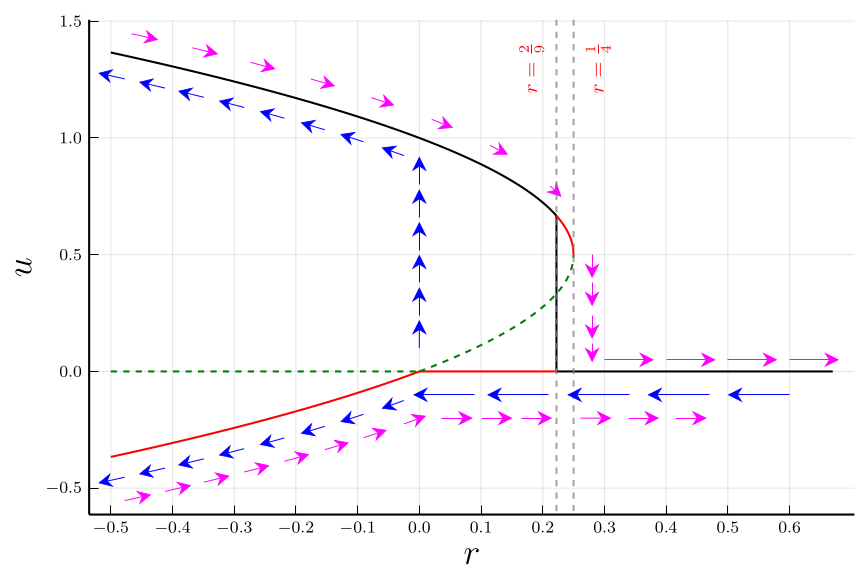

In [67]:
r1 = LinRange(-0.5,2/9,200)
r2 = LinRange(-0.5,0.0,200)
r9 = LinRange(-0.5,0.25,200)
r3 = LinRange(2/9,0.67,30)
r4 = LinRange(2/9,0.25,30)
r5 = LinRange(0,2/9,200)
r6 = LinRange(0,0.25,200)
r7 =  LinRange(0.03,2/9 -0.05,200)
r71 =  LinRange(0.03,2/9 -0.01,200)
r8 = LinRange(0,1,200)
plot(r1, (@. 0.5 + sqrt(0.25 -r1)), c="black", label="")
plot!(r2, (@. 0.5 - sqrt(0.25 -r2)), c="red", label="")
plot!(r3, zeros(length(r3)), c="black", label="")
plot!([2/9, 2/9], [0,2/3],c="black", label="")
plot!(r4, (@. 0.5 + sqrt(0.25 -r4)), c="red", label="")
plot!(r5, zeros(length(r5)), c="red", label="")
plot!([-0.5,0],[0,0], ls=:dash, c="green", label="")
plot!(r6, (@. 0.5 - sqrt(0.25 -r6)), ls=:dash, c="green", label="")
xlabel!(L"r")
ylabel!(L"u")
plot!(guidefontsize=15, labelfontsize=18)
u_upper(r) = 0.5 + sqrt(0.25 - r)
u_lower(r) = 0.5 - sqrt(0.25 - r)

# Upper black branch (increasing r)
add_tangent_arrows!(r9, u_upper.(r9) .+0.1, dir=:right, col=:magenta)

# Lower red branch (increasing r)
add_tangent_arrows!(r2, u_lower.(r2) .-0.2, dir=:right, col=:magenta)

# Zero branch right side (decreasing r)
# add_tangent_arrows!(r3, zeros(length(r3)) .- 0.1, dir=:left, col=:blue, n_arrows=3)
add_tangent_arrows!(r3 .-0.1, zeros(length(r3)) .- 0.2, dir=:right, col=:magenta, n_arrows=3)
add_tangent_arrows!(r7, zeros(length(r7)) .- 0.2, dir=:right, col=:magenta, n_arrows=3)

add_tangent_arrows!(r2, u_upper.(r2) .- 0.1, dir=:left, col=:blue)
add_tangent_arrows!(r2, u_lower.(r2) .- 0.1, dir=:left, col=:blue)


# add_tangent_arrows!(r71 .+0.02, zeros(length(r7)) .- 0.1, dir=:left, col=:blue, n_arrows=4)

# add_tangent_arrows!(zeros(length(r7)),  r8 , dir=:left, col=:blue, n_arrows=3)

vline!([2/9, 1/4], ls=:dash, c="grey", alpha=0.7, label="")

x = zeros(6)
y = [0.1,0.24,0.38,0.52,0.66,0.8]
# Direction vectors (vertical arrows of length 1)
u = fill(0.0, 6)
v = fill(0.12,6)

quiver!(x, y, quiver=(u, v), arrow=(:closed,7),color="blue", label="")



y = -0.1 .* ones(5)
x = [0.6, 0.47, 0.34, 0.21, 0.09]
# Direction vectors (vertical arrows of length 1)
v = fill(0.0, 5)
u = fill(-0.1, 5)

quiver!(x, y, quiver=(u, v), arrow=(:closed,7),color="blue", label="")
plot!(xticks=-0.5:0.1:0.6)


y = 0.05 .* ones(4)
x = [0.3, 0.4,0.5, 0.6]
# Direction vectors (vertical arrows of length 1)
v = fill(0.0, 4)
u = fill(0.08, 4)

quiver!(x, y, quiver=(u, v), arrow=(:closed,7),color="magenta", label="")




x = fill(0.28,4)
y = [0.5, 0.38,0.24,0.12]
# Direction vectors (vertical arrows of length 1)
u = fill(0.0, 4)
v = [-0.1,-0.1,-0.1,-0.08]

quiver!(x, y, quiver=(u, v), arrow=(:closed,7),color="magenta", label="")
annotate!(2/9-0.04,1.3,text(L"r = \frac{2}{9}", :red, 10,rotation=90))
annotate!(0.25+0.04,1.3,text(L"r = \frac{1}{4}", :red, 10,rotation=90))

In [68]:
savefig("m4hyst.pdf")

"/home/shaggy1304/Notes/AdvStatMech/codes/m4hyst.pdf"

sextic potential

In [98]:
r1 = LinRange(-0.5,0,200)
r2 = LinRange(0,3/16,200)
r3 = LinRange(3/16,0.25,200)
r4 = LinRange(1/4, 0.65, 200)


l1 = (@. sqrt(0.5 + sqrt(0.25 -r1)))
l2 = (@. -sqrt(0.5 + sqrt(0.25 -r1)));

l3 = (@. sqrt(0.5 + sqrt(0.25 -r2)));
l4 = (@. -sqrt(0.5 + sqrt(0.25 -r2)));
l5 = (@. sqrt(0.5 - sqrt(0.25 -r2)));
l6 = (@. -sqrt(0.5 - sqrt(0.25 -r2)));


l7 = (@. sqrt(0.5 + sqrt(0.25 -r3)));
l8 = (@. -sqrt(0.5 + sqrt(0.25 -r3)));
l9 = (@. sqrt(0.5 - sqrt(0.25 -r3)));
l10 = (@. -sqrt(0.5 - sqrt(0.25 -r3)));

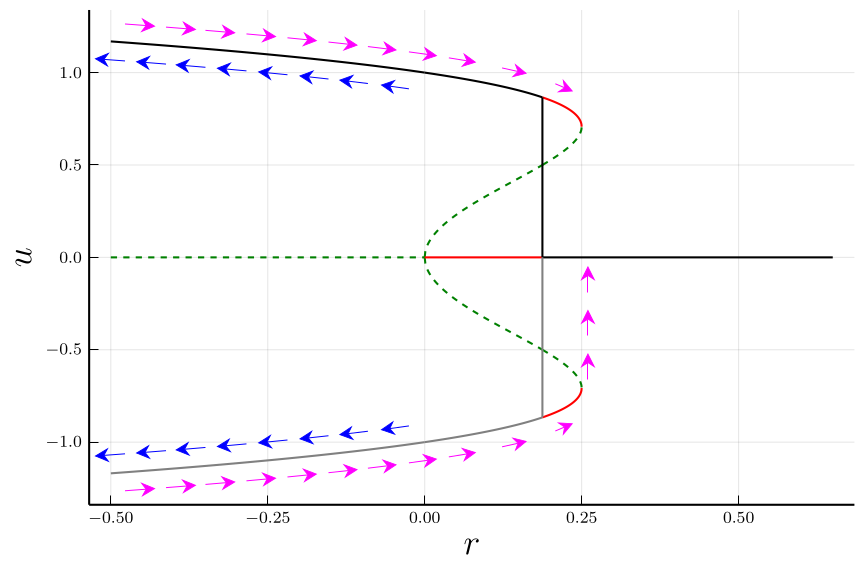

In [113]:
# pgfplotsx()
plot(r1, l1, c="black", label="")
plot!(r1, l2, c="grey", label="")

plot!(r2, l3, c="black", label="")
plot!(r2, l4, c="grey", label="")
plot!(r2, l5, c="green", label="", ls=:dash)
plot!(r2, l6, c="green", label="", ls=:dash)

plot!(r3, l7, c="red", label="")
plot!(r3, l8, c="red", label="")
plot!(r3, l9, c="green", label="", ls=:dash)
plot!(r3, l10, c="green", label="", ls=:dash)

plot!([-0.5,0], [0,0], ls=:dash, c="green", label="")
plot!([0,3/16], [0,0], c="red", label="")
plot!([3/16, 0.65], [0,0], c="black", label="")
xlabel!(L"r")
ylabel!(L"u")
plot!(guidefontsize=15, labelfontsize=18)
plot!([3/16, 3/16], [0,sqrt(3)/2], c="black", label="")
plot!([3/16, 3/16], [0,-sqrt(3)/2], c="grey", label="")
u_upper(r) = sqrt(0.5 + sqrt(0.25 - r))
u_lower(r) = -sqrt(0.5 + sqrt(0.25 - r))

# # Upper black branch (increasing r)
add_tangent_arrows!(r1, u_upper.(r1) .+0.1, dir=:right, col=:magenta)
add_tangent_arrows!(r2 .+ 0.03, u_upper.(r2 .+ 0.03) .+0.1, dir=:right, col=:magenta, n_arrows=3)

add_tangent_arrows!(r1, u_lower.(r1) .-0.1, dir=:right, col=:magenta)
add_tangent_arrows!(r2 .+ 0.03, u_lower.(r2 .+ 0.03) .-0.1, dir=:right, col=:magenta, n_arrows=3)




add_tangent_arrows!(r1, u_upper.(r1) .-0.1, dir=:left, col=:blue)
# add_tangent_arrows!(r2 .+ 0.03, u_upper.(r2 .+ 0.03) .-0.1, dir=:left, col=:blue, n_arrows=3)

add_tangent_arrows!(r1, u_lower.(r1) .+0.1, dir=:left, col=:blue)
# add_tangent_arrows!(r2 .+ 0.03, u_lower.(r2 .+ 0.03) .-0.1, dir=:left, col=:blue, n_arrows=3)





c = -1/sqrt(2)
n = 3
α = 0.6                # smaller → bigger gap

segment = abs(c)/n
arrowlen = α*segment

# segment centers
centers = LinRange(c + segment/2, -segment/2, n)

# start slightly below center so arrow sits inside segment
y = centers .- arrowlen/2

x = fill(0.26, n)

u = zeros(n)
v = fill(arrowlen, n)

quiver!(x, y,
        quiver=(u, v),
        arrow=(:closed,7),
        color="magenta",
        label="")





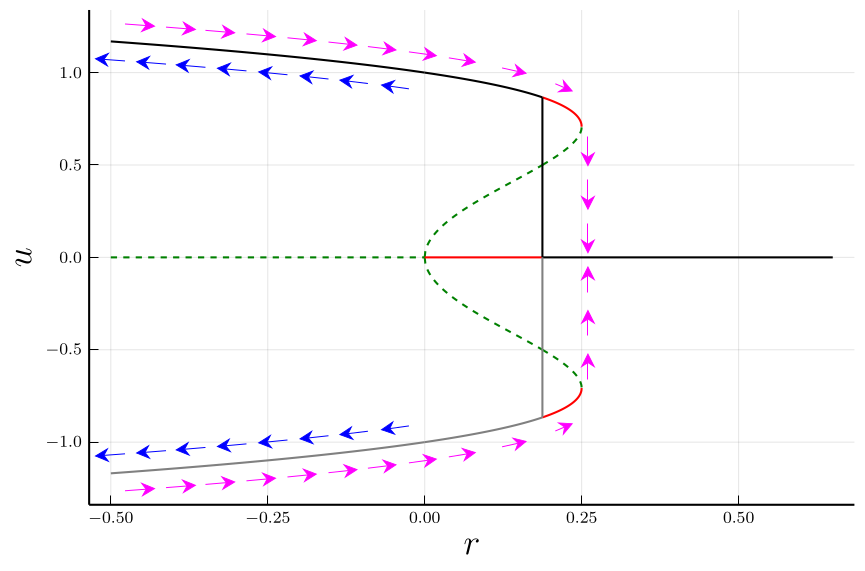

In [114]:
a = 0.15
b = 1/sqrt(2) + 0.15
n = 3
α = 0.7

segment  = (b - a)/n
arrowlen = α*segment
centers  = LinRange(a + segment/2, b - segment/2, n)

y = centers .- arrowlen/2
x = fill(0.26, n)

u = zeros(n)
v = fill(-arrowlen, n)

quiver!(x, y, quiver=(u,v),
        arrow=(:closed,7), color="magenta", label="")


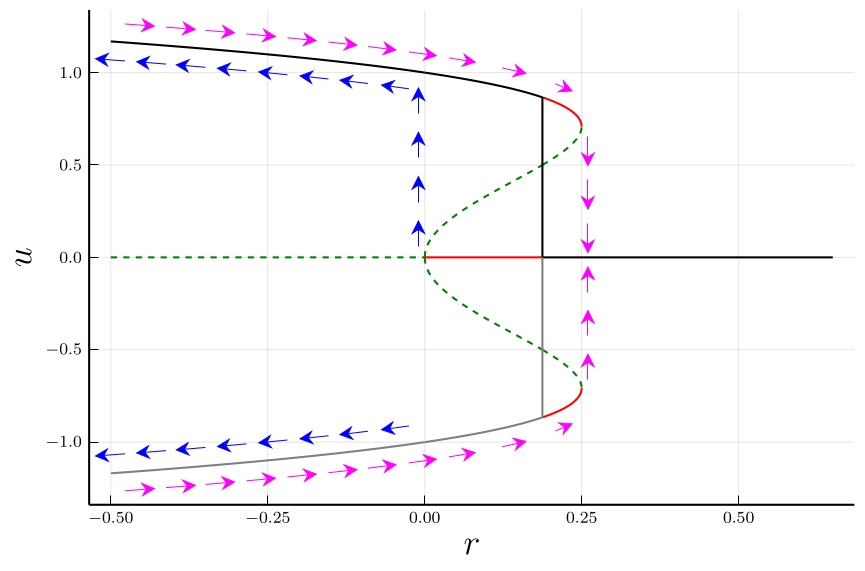

In [115]:
a = 0.01
b = 0.97
n = 4
α = 0.6

segment  = (b - a)/n
arrowlen = α*segment
centers  = LinRange(a + segment/2, b - segment/2, n)

y = centers .- arrowlen/2
x = fill(-0.01, n)

u = zeros(n)
v = fill(arrowlen, n)

quiver!(x, y, quiver=(u,v),
        arrow=(:closed,7), color="blue", label="")


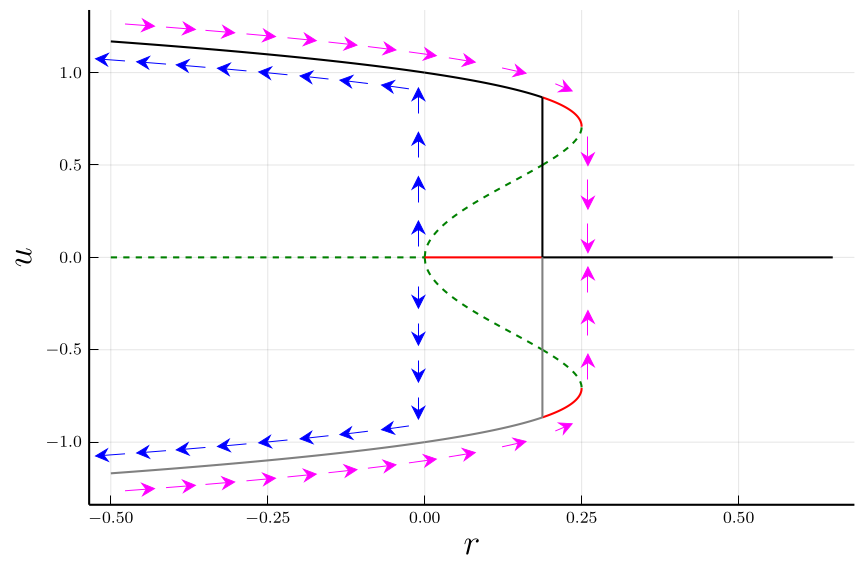

In [116]:
a = -0.8
b = 0
n = 4
α = 0.6

segment  = (b - a)/n
arrowlen = α*segment
centers  = LinRange(a + segment/2, b - segment/2, n)

y = centers .- arrowlen/2
x = fill(-0.01, n)

u = zeros(n)
v = fill(-arrowlen, n)

quiver!(x, y, quiver=(u,v),
        arrow=(:closed,7), color="blue", label="")


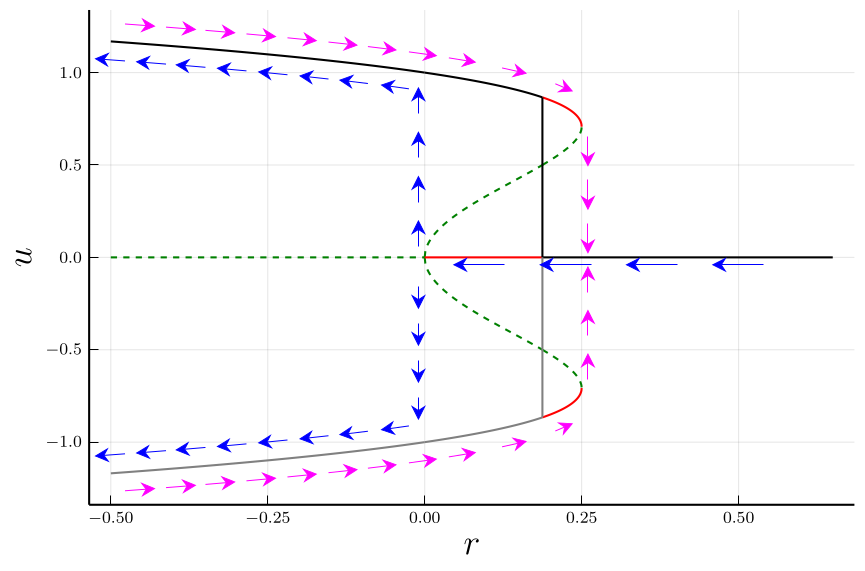

In [117]:
a = 0.1
b = 0.65
n = 4
α = 0.6

segment  = (b - a)/n
arrowlen = α*segment
centers  = LinRange(a + segment/2, b - segment/2, n)

x = centers .- arrowlen/2
y = fill(-0.04, n)

u = fill(-arrowlen, n)
v = zeros(n)

quiver!(x, y, quiver=(u,v),
        arrow=(:closed,7), color="blue", label="")


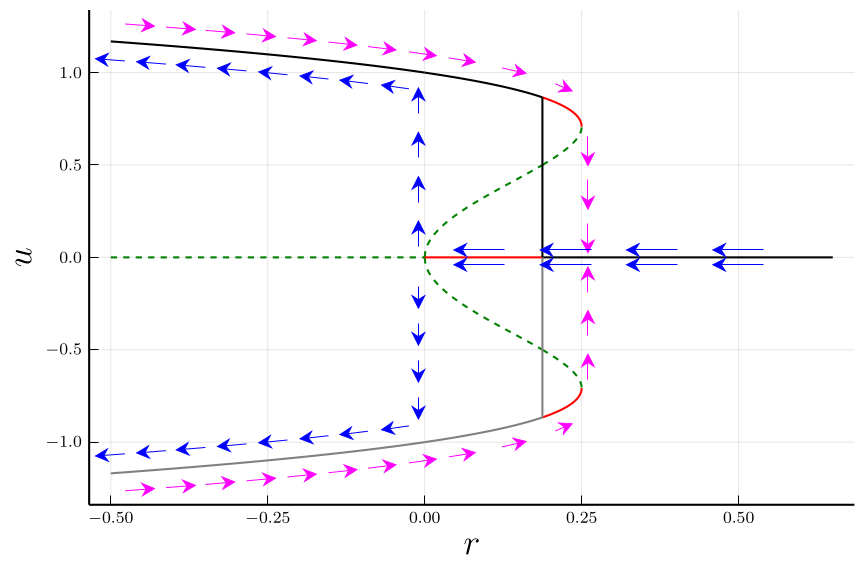

In [118]:
a = 0.1
b = 0.65
n = 4
α = 0.6

segment  = (b - a)/n
arrowlen = α*segment
centers  = LinRange(a + segment/2, b - segment/2, n)

x = centers .- arrowlen/2
y = fill(0.04, n)

u = fill(-arrowlen, n)
v = zeros(n)

quiver!(x, y, quiver=(u,v),
        arrow=(:closed,7), color="blue", label="")


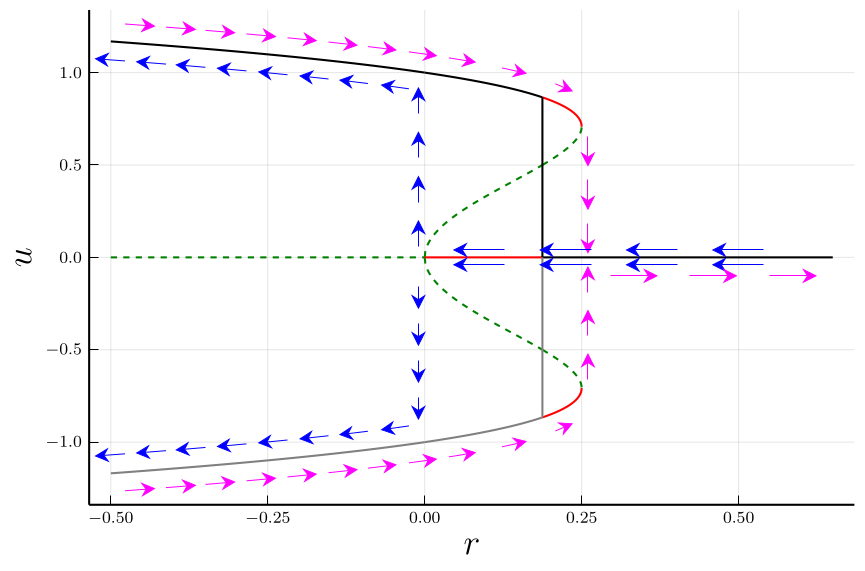

In [119]:
a = 0.27
b = 0.65
n = 3
α = 0.6

segment  = (b - a)/n
arrowlen = α*segment
centers  = LinRange(a + segment/2, b - segment/2, n)

x = centers .- arrowlen/2
y = fill(-0.1, n)

u = fill(arrowlen, n)
v = zeros(n)

quiver!(x, y, quiver=(u,v),
        arrow=(:closed,7), color="magenta", label="")


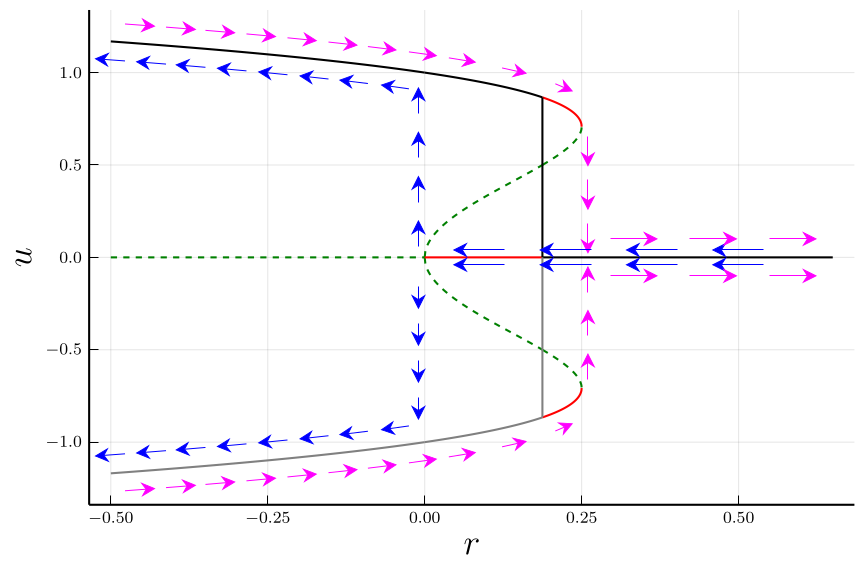

In [120]:
a = 0.27
b = 0.65
n = 3
α = 0.6

segment  = (b - a)/n
arrowlen = α*segment
centers  = LinRange(a + segment/2, b - segment/2, n)

x = centers .- arrowlen/2
y = fill(0.1, n)

u = fill(arrowlen, n)
v = zeros(n)

quiver!(x, y, quiver=(u,v),
        arrow=(:closed,7), color="magenta", label="")


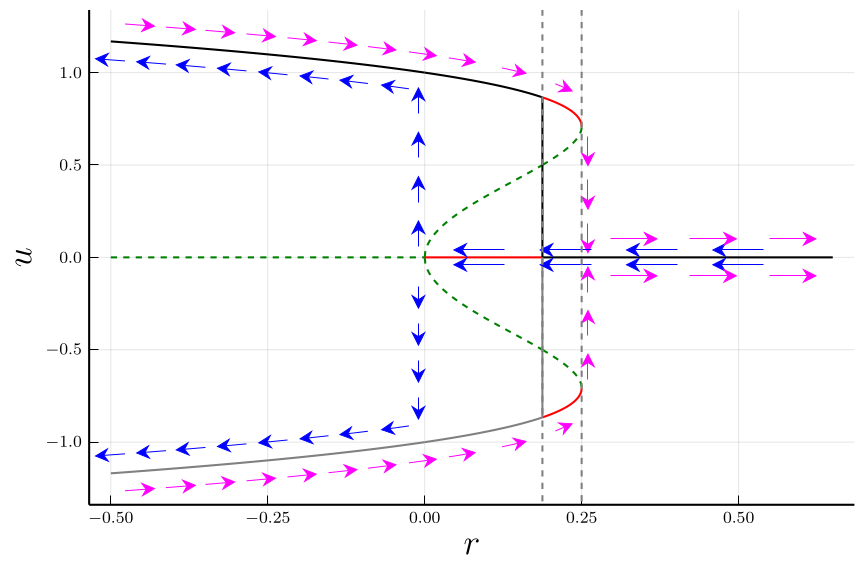

In [121]:
vline!([3/16, 1/4], ls=:dash, c="grey", label="")

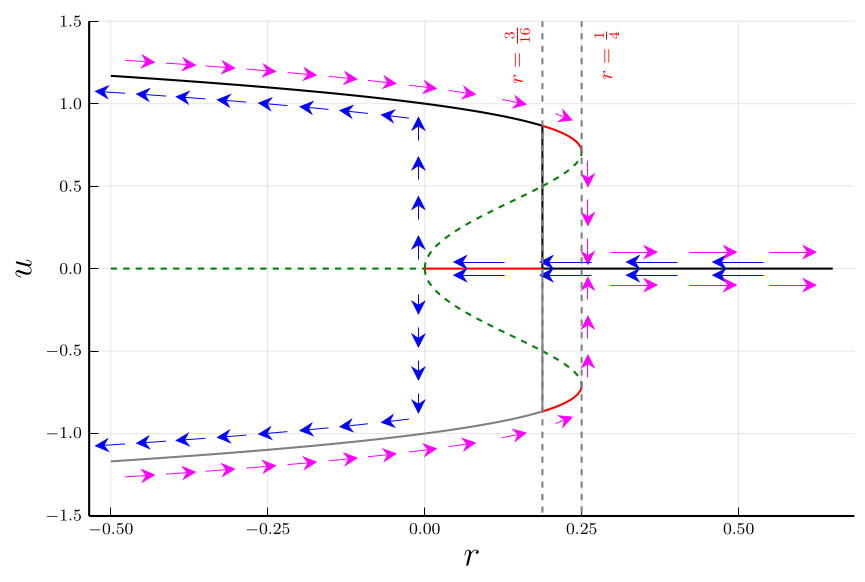

In [122]:
annotate!(3/16-0.04,1.3,text(L"r = \frac{3}{16}", :red, 10,rotation=90))
annotate!(0.25+0.04,1.3,text(L"r = \frac{1}{4}", :red, 10,rotation=90))
ylims!(-1.5,1.5)

In [123]:
savefig("hystm6.pdf")

"/home/shaggy1304/IISER/IISER_Courses/Notes/AdvStatMech/codes/hystm6.pdf"